In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/amazon_sales_cleaned.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/amazon_sales_cleaned.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [6]:
total_sales = df["TotalAmount"].sum()
total_orders = df["OrderID"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["ProductID"].nunique()
total_units = df["Quantity"].sum()
average_order_value = total_sales / total_orders

print("===== AMAZON SALES KPIs =====")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

===== AMAZON SALES KPIs =====
Total Sales: ₹91,825,647.92
Total Orders: 100,000
Total Customers: 43,233
Total Products: 50
Total Units Sold: 300,140
Average Order Value: ₹918.26


In [7]:
# Order Status Analysis

order_status = df["OrderStatus"].value_counts()

print("===== ORDER STATUS =====")
display(order_status)

===== ORDER STATUS =====


OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64

In [8]:
# Order Status Percentage

order_status_percentage = (
    df["OrderStatus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("===== ORDER STATUS PERCENTAGE =====")
display(order_status_percentage)

===== ORDER STATUS PERCENTAGE =====


OrderStatus
Delivered    74.63
Shipped      15.19
Pending       4.10
Returned      3.05
Cancelled     3.03
Name: proportion, dtype: float64

In [9]:
# Category-wise Sales Analysis

category_sales = (
    df.groupby("Category")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== SALES BY CATEGORY =====")
display(category_sales)

===== SALES BY CATEGORY =====


Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

In [10]:
# Brand-wise Sales Analysis

brand_sales = (
    df.groupby("Brand")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 BRANDS BY SALES =====")
display(brand_sales.head(10))

===== TOP 10 BRANDS BY SALES =====


Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64

In [11]:
# Top 10 Products by Sales

product_sales = (
    df.groupby("ProductName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 PRODUCTS BY SALES =====")
display(product_sales.head(10))

===== TOP 10 PRODUCTS BY SALES =====


ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64

In [12]:
# Top 10 Products by Quantity Sold

product_quantity = (
    df.groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 PRODUCTS BY QUANTITY =====")
display(product_quantity.head(10))

===== TOP 10 PRODUCTS BY QUANTITY =====


ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64

In [13]:
# Top 10 Customers by Sales

customer_sales = (
    df.groupby(["CustomerID", "CustomerName"])["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 CUSTOMERS BY SALES =====")
display(customer_sales.head(10))

===== TOP 10 CUSTOMERS BY SALES =====


CustomerID  CustomerName 
CUST010696  Pooja Patel      5436.04
CUST035973  Neha Sharma      5124.43
CUST009614  Vikas Mehta      5003.65
CUST018720  Arjun Kapoor     4773.18
CUST022824  Pooja Joshi      4755.48
CUST008882  Sneha Reddy      4730.47
CUST022031  Priya Kapoor     4266.02
CUST031449  Vivaan Kapoor    4253.27
CUST005523  Sahil Patel      4239.18
CUST047013  Arjun Kumar      4222.62
Name: TotalAmount, dtype: float64

In [14]:
# Customer Purchase Frequency

customer_orders = (
    df.groupby("CustomerID")["OrderID"]
    .nunique()
)

print("===== CUSTOMER PURCHASE FREQUENCY =====")
print("One-time Customers:", (customer_orders == 1).sum())
print("Repeat Customers:", (customer_orders > 1).sum())
print("Total Customers:", customer_orders.nunique())

===== CUSTOMER PURCHASE FREQUENCY =====
One-time Customers: 13532
Repeat Customers: 29701
Total Customers: 10


In [15]:
# Customer Revenue Segmentation

customer_sales = (
    df.groupby("CustomerID")["TotalAmount"]
    .sum()
)

customer_segment = pd.cut(
    customer_sales,
    bins=[0, 5000, 20000, 50000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value", "VIP"]
)

segment_summary = customer_segment.value_counts().sort_index()

print("===== CUSTOMER SEGMENTS =====")
display(segment_summary)

===== CUSTOMER SEGMENTS =====


TotalAmount
Low Value       40660
Medium Value     2573
High Value          0
VIP                 0
Name: count, dtype: int64

In [16]:
# State-wise Sales Analysis

state_sales = (
    df.groupby("State")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 STATES BY SALES =====")
display(state_sales.head(10))

===== TOP 10 STATES BY SALES =====


State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
Name: TotalAmount, dtype: float64

In [17]:
# City-wise Sales Analysis

city_sales = (
    df.groupby("City")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 10 CITIES BY SALES =====")
display(city_sales.head(10))

===== TOP 10 CITIES BY SALES =====


City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Denver          4638498.97
Austin          4638403.18
Chicago         4632847.44
Los Angeles     4620629.78
Columbus        4615442.32
Name: TotalAmount, dtype: float64

In [18]:
# Payment Method Analysis

payment_analysis = (
    df["PaymentMethod"]
    .value_counts()
)

print("===== PAYMENT METHOD ANALYSIS =====")
display(payment_analysis)

===== PAYMENT METHOD ANALYSIS =====


PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64

In [19]:
# Payment Method-wise Sales

payment_sales = (
    df.groupby("PaymentMethod")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("===== SALES BY PAYMENT METHOD =====")
display(payment_sales)

===== SALES BY PAYMENT METHOD =====


PaymentMethod
Credit Card         32122158.69
Debit Card          18538678.53
UPI                 13896028.55
Amazon Pay          13697498.42
Net Banking          9055674.57
Cash on Delivery     4515609.16
Name: TotalAmount, dtype: float64

In [20]:
# Monthly Sales Trend

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"]
    .sum()
)

print("===== MONTHLY SALES =====")
display(monthly_sales)

===== MONTHLY SALES =====


OrderDate
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82


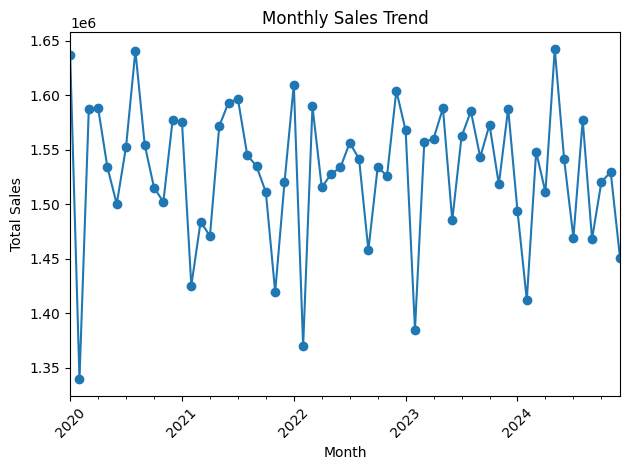

In [21]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

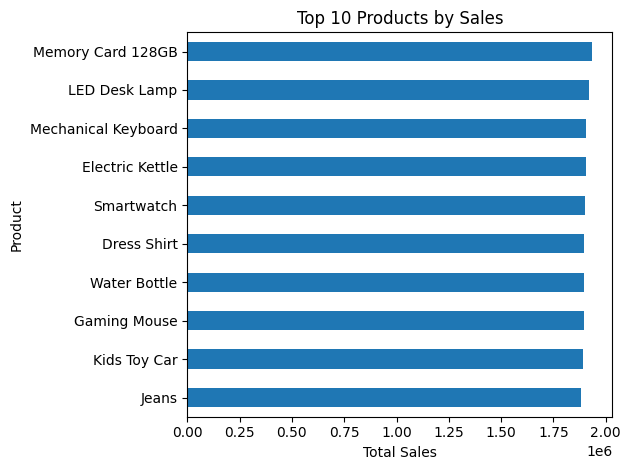

In [7]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

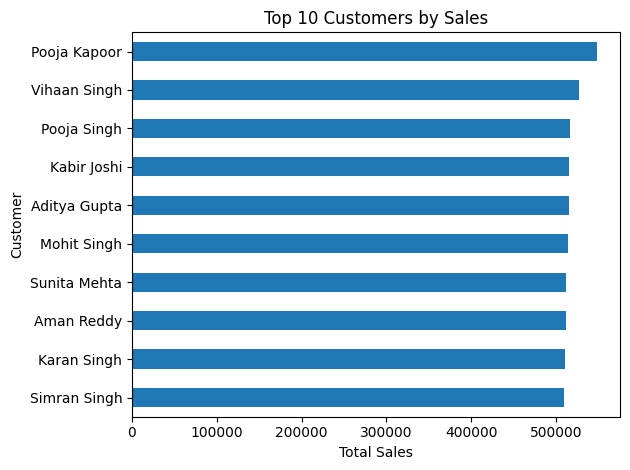

In [8]:
# Top 10 Customers by Sales - Chart

top_customers = (
    df.groupby("CustomerName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

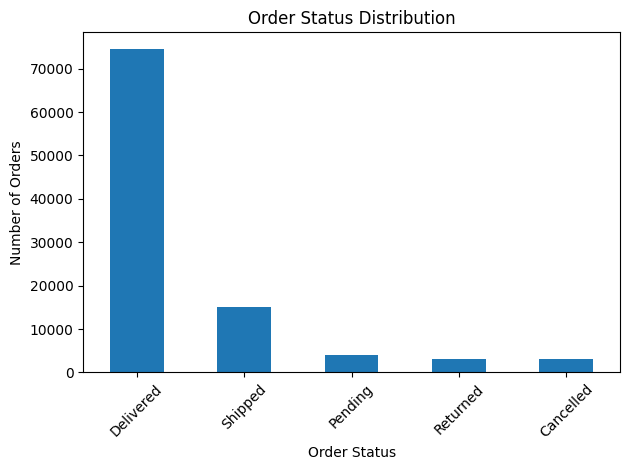

In [9]:
# Order Status Distribution - Chart

status_counts = df["OrderStatus"].value_counts()

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

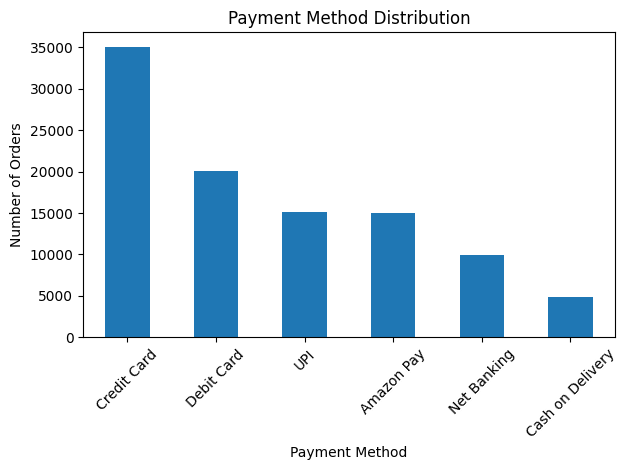

In [10]:
# Payment Method Distribution - Chart

payment_counts = df["PaymentMethod"].value_counts()

payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

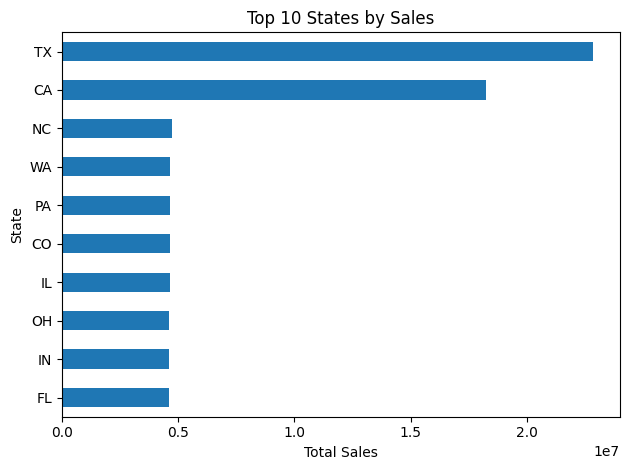

In [11]:
# Top 10 States by Sales - Chart

top_states = (
    df.groupby("State")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states.sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

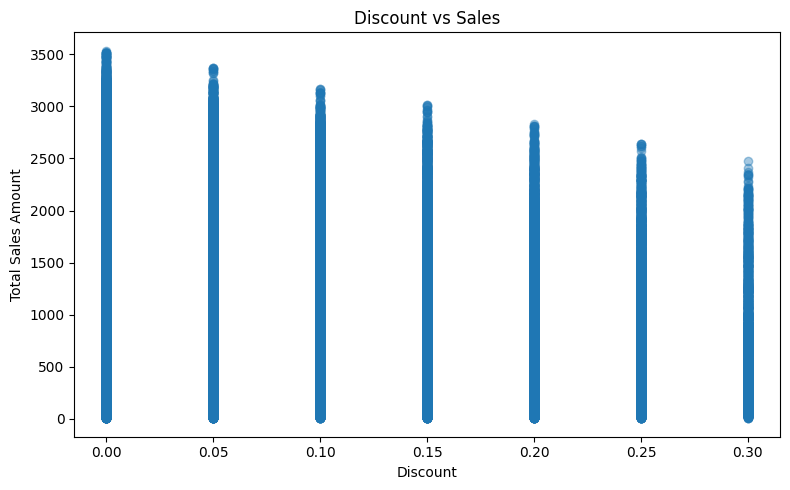

In [12]:
# Discount vs Sales Analysis

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["TotalAmount"],
    alpha=0.4
)

plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Total Sales Amount")

plt.tight_layout()
plt.show()

In [2]:
print("Total Orders:", df["OrderID"].nunique())
print("Total Customers:", df["CustomerID"].nunique())
print("Total Products:", df["ProductID"].nunique())
print("Total Categories:", df["Category"].nunique())
print("Total Brands:", df["Brand"].nunique())

Total Orders: 100000
Total Customers: 43233
Total Products: 50
Total Categories: 6
Total Brands: 10


In [3]:
# Check all numeric columns first
print("Numeric Columns:")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

Numeric Columns:
['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']


In [4]:
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']


In [13]:
# Key Business Metrics

metrics = {
    "Total Sales": df["TotalAmount"].sum(),
    "Total Orders": df["OrderID"].nunique(),
    "Total Customers": df["CustomerID"].nunique(),
    "Total Units Sold": df["Quantity"].sum(),
    "Average Order Value": df["TotalAmount"].sum() / df["OrderID"].nunique(),
    "Average Discount": df["Discount"].mean(),
    "Average Shipping Cost": df["ShippingCost"].mean(),
    "Average Tax": df["Tax"].mean()
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

display(metrics_df)

,Metric,Value
0,Total Sales,9.182565e+07
1,Total Orders,1.000000e+05
2,Total Customers,4.323300e+04
3,Total Units Sold,3.001400e+05
4,Average Order Value,9.182565e+02
5,Average Discount,7.422600e-02
6,Average Shipping Cost,7.406660e+00
7,Average Tax,6.846890e+01


# Key Business Insights

## Sales Performance
- Total sales generated: ₹[VALUE]
- Total orders: [VALUE]
- Average order value: ₹[VALUE]

## Product Performance
- The highest-performing product by sales was [PRODUCT].
- The highest-selling category was [CATEGORY].
- The top-performing brand was [BRAND].

## Customer Insights
- Total customers: [VALUE]
- Repeat customers: [VALUE]
- One-time customers: [VALUE]

## Geographic Insights
- The highest-sales state was [STATE].
- The highest-sales city was [CITY].

## Order & Payment Insights
- The most common order status was [STATUS].
- The most commonly used payment method was [PAYMENT METHOD].

## Key Takeaway
The analysis highlights the major sales drivers, customer behavior patterns, product performance, and geographic opportunities within the business.